# GNSS Observation Gap Analysis
This notebook uses the GNSS Observation tileDB array to identify, analyze and plot gaps in the campaign data by survey. 
***

## Import packages 

In [1]:
import json
from datetime import datetime, timezone
import numpy as np
from pathlib import Path
import tiledb
import matplotlib.pyplot as plt

## Load gnss observation tileDB array for campaign

Set the `network`, `campaign`, and `station` you want to view data for as well as the path to the data. 

In [23]:
# Define constants and paths
NETWORK = "cascadia-gorda"
STATION = "NCC1"
CAMPAIGN = "2025_A_1126"
PROJECT_DIRECTORY = str(Path.home() / "data/sfg_march17")

# Define path to the TileDB array and read data
array_uri = f"{PROJECT_DIRECTORY}/{NETWORK}/{STATION}/TileDB/gnss_obs.tdb"
A = tiledb.open(array_uri, 'r')
data = A[:]

## Load survey metadata for campaign

Set the path to the json metadata file. Survey information will be printed below.

In [5]:
# Set path to metadata file
METADATA_PATH = "/Users/terry/repos/seafloor_geodesy_notebooks/NCC1.json"

# Load metadata file
with open(METADATA_PATH, 'r') as f:
    metadata = json.load(f)

# Grab the current campaign year from the CAMPAIGN variable and filter metadata for campaigns that match the year
CAMPAIGN_YEAR = CAMPAIGN.split('_')[0]
campaigns = [c for c in metadata['campaigns'] if c['name'].startswith(CAMPAIGN_YEAR)]

surveys = {}
for campaign in campaigns:
    for survey in campaign['surveys']:
        start_dt = datetime.strptime(survey['start'], '%Y-%m-%dT%H:%M:%S').replace(tzinfo=timezone.utc)
        end_dt = datetime.strptime(survey['end'], '%Y-%m-%dT%H:%M:%S').replace(tzinfo=timezone.utc)
        print(f"Survey: {survey['id']}, Start: {start_dt}, End: {end_dt}")

        # Convert to POSIX timestamp in milliseconds
        start_int = int(start_dt.timestamp() * 1000)
        end_int = int(end_dt.timestamp() * 1000)

        # survey stats
        survey_duration_seconds = (end_dt - start_dt).total_seconds()
        print(f"Survey duration (seconds): {survey_duration_seconds}")

        # Separate the tileDB data into survey-specific subsets dataframes
        df = A.df[slice(start_int, end_int)]

        # Assuming 'time' is the column with timestamps in milliseconds
        time_sorted = np.sort(df['time'].values)
        diffs = np.diff(time_sorted)

        surveys[survey['id']] = {
            "start": start_dt,
            "end": end_dt,
            "duration_seconds": survey_duration_seconds,
            "num_observations": len(df),
            "time_diffs": diffs
        }


Survey: 2025_A_1126_1, Start: 2025-09-07 20:27:00+00:00, End: 2025-09-08 13:40:00+00:00
Survey duration (seconds): 61980.0
Survey: 2025_A_1126_2, Start: 2025-09-08 13:40:00+00:00, End: 2025-09-12 19:33:00+00:00
Survey duration (seconds): 366780.0
Survey: 2025_A_1126_3, Start: 2025-09-12 19:33:00+00:00, End: 2025-09-13 07:12:00+00:00
Survey duration (seconds): 41940.0


## Analyze gaps in survey data


Analyzing survey: 2025_A_1126_1


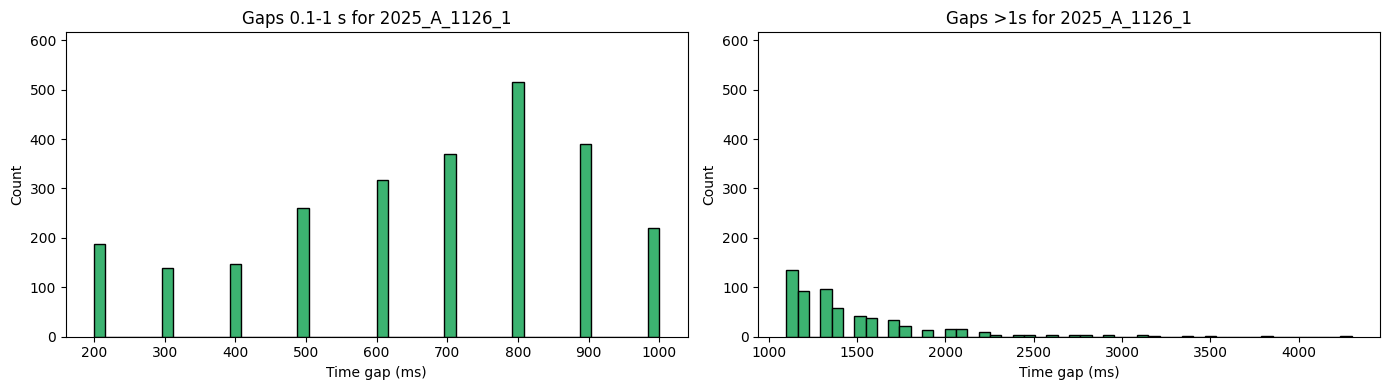

Total number of observations: 20386386
Expected gap size at 10 Hz: 100.0 ms
Total Number of gaps > 100.0 ms: 3153
Percent of gaps based on expected observations: 0.51%

Analyzing survey: 2025_A_1126_2


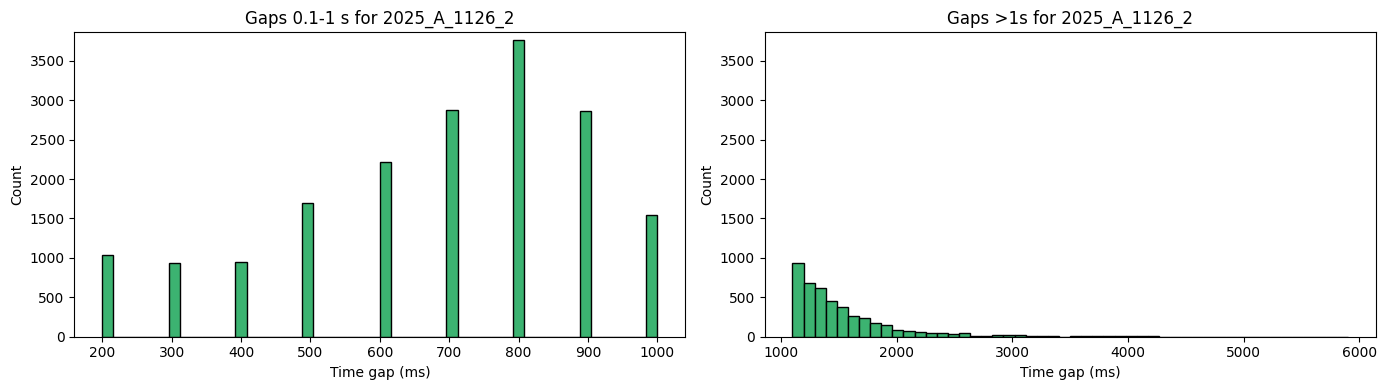

Total number of observations: 116823926
Expected gap size at 10 Hz: 100.0 ms
Total Number of gaps > 100.0 ms: 22309
Percent of gaps based on expected observations: 0.61%

Analyzing survey: 2025_A_1126_3


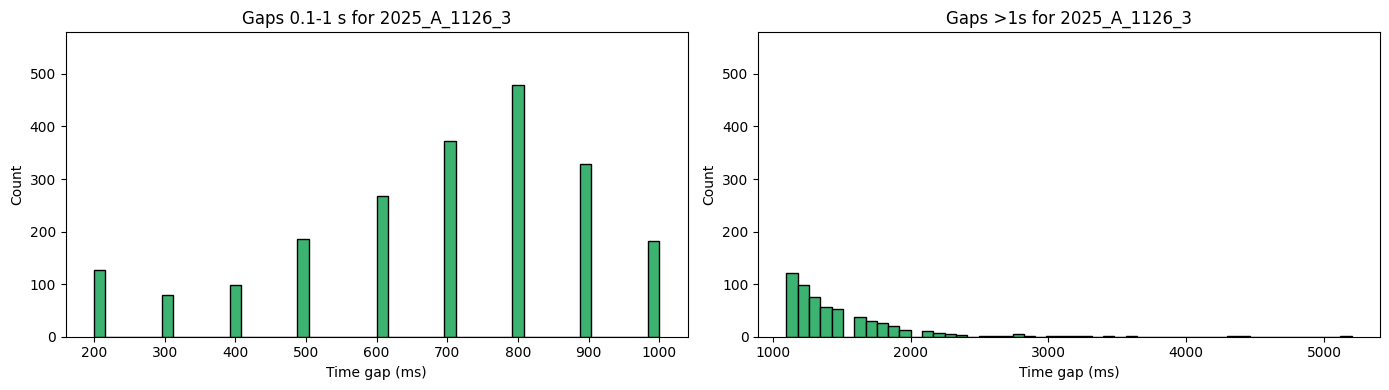

Total number of observations: 13381456
Expected gap size at 10 Hz: 100.0 ms
Total Number of gaps > 100.0 ms: 2700
Percent of gaps based on expected observations: 0.64%


In [20]:
HZ = 10
expected_gap_size = 1000 / HZ

for survey_id, survey_info in surveys.items():
    print(f"\nAnalyzing survey: {survey_id}")
    diffs = survey_info["time_diffs"]
    
    # Gaps between 100ms and 1000ms
    gaps_100_1000 = diffs[(diffs > 100) & (diffs <= 1000)]
    
    # Gaps above 1000ms
    gaps_above_1000 = diffs[diffs > 1000]
    
    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    
    # Plot 1: Gaps 100-1000 ms
    ax1.hist(gaps_100_1000, bins=50, color='mediumseagreen', edgecolor='black')
    ax1.set_title(f"Gaps 0.1-1 s for {survey_id}")
    ax1.set_xlabel("Time gap (ms)")
    ax1.set_ylabel("Count")
    
    # Plot 2: Gaps above 1000ms
    ax2.hist(gaps_above_1000, bins=50, color='mediumseagreen', edgecolor='black')
    ax2.set_title(f"Gaps >1s for {survey_id}")
    ax2.set_xlabel("Time gap (ms)")
    ax2.set_ylabel("Count")

    # Set both plots to have the same y-axis limits for better comparison
    max_count = max(max(np.histogram(gaps_100_1000, bins=50)[0]), max(np.histogram(gaps_above_1000, bins=50)[0]))
    ax1.set_ylim(0, max_count+100)
    ax2.set_ylim(0, max_count+100)
    
    plt.tight_layout()
    plt.show()
    
    # Show stats for gaps
    print(f"Total number of observations: {survey_info['num_observations']}")
    print(f"Expected gap size at {HZ} Hz: {expected_gap_size} ms")
    total_gaps = len(diffs[diffs > expected_gap_size])
    print(f"Total Number of gaps > {expected_gap_size} ms: {total_gaps}")
    # Percent of gaps based on total seconds and hertz
    total_seconds = survey_info["duration_seconds"]
    expected_observations = total_seconds * HZ
    percent_gaps = (total_gaps / expected_observations) * 100
    print(f"Percent of gaps based on expected observations: {percent_gaps:.2f}%")
    # Percent of gaps between 100-1000ms